    post under_post org_nummer        verdi periode land valuta
0  20450         00  351728748  62231248.25  202309   DK    NOK
1  22800         00  864536539  42881484.96  202106   NO    NOK
2  20550         00  983061213   3153656.15  202312   SE    EUR
3  20300         00  292924168  20356576.20  202309   DK    EUR
4  20200         00  945160866  23804622.85  202309   SE    EUR
    post under_post org_nummer        verdi periode land valuta  post_code  \
0  20450         00  351728748  62231248.25  202309   DK    NOK      20450   
1  22800         00  864536539  42881484.96  202106   NO    NOK      22800   
2  20550         00  983061213   3153656.15  202312   SE    EUR      20550   
3  20300         00  292924168  20356576.20  202309   DK    EUR      20300   
4  20200         00  945160866  23804622.85  202309   SE    EUR      20200   

   periode_code  anomaly  
0        202309        1  
1        202106        1  
2        202312        1  
3        202309        1  
4        202

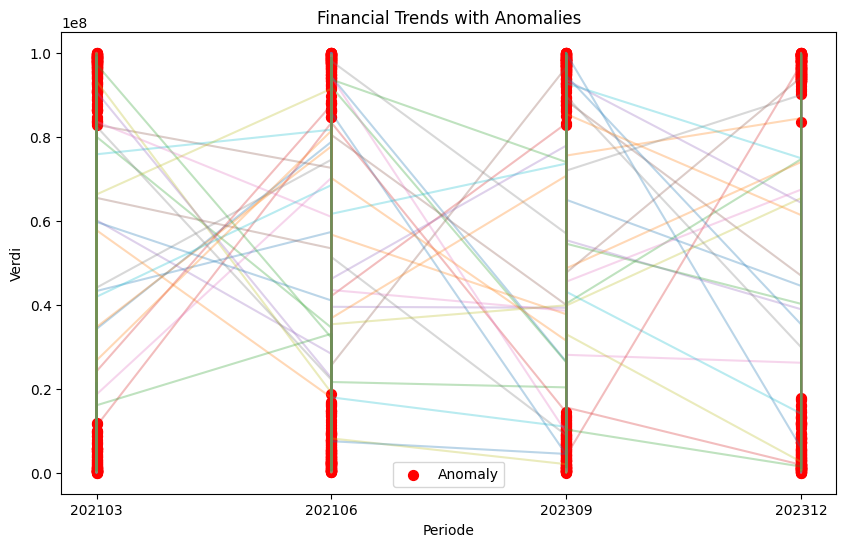

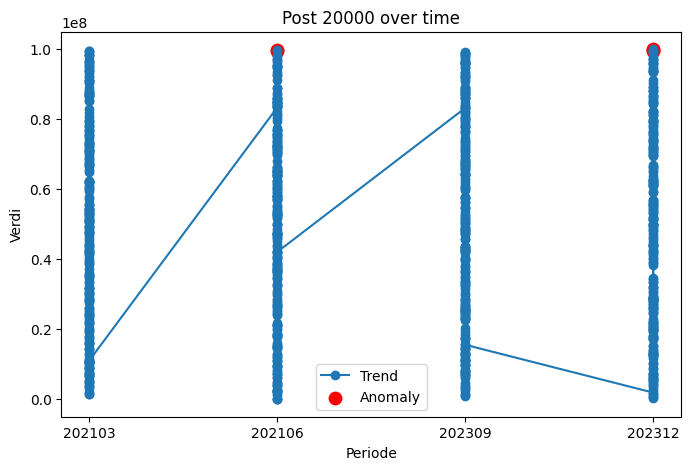

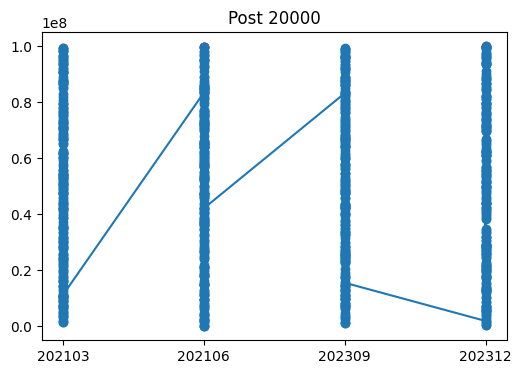

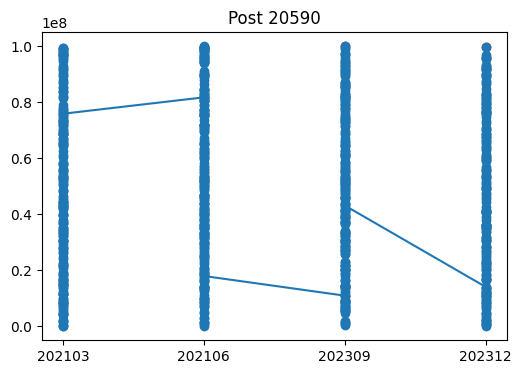

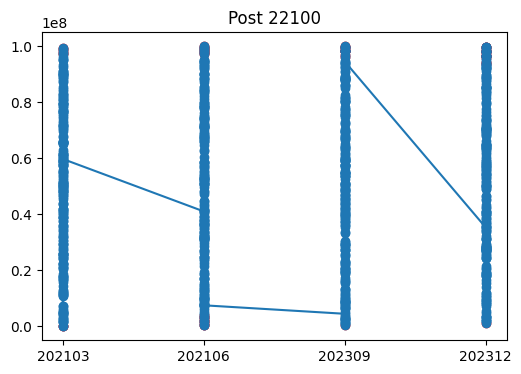

In [ ]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.ensemble import IsolationForest

# +
# ONLY your selected posts
poster = [
    # EGENKAPITAL
    "20000","20100","20200","20300",
    "20410","20420","20450","20550","20590","20800",

    # FOREIGN OWNERSHIP
    "20001","20002","20003","20004",

    # LONG-TERM DEBT
    "21300","21600","22000","22100",
    "22200","22500","22600","22800","22900"]

valutaer = ["NOK","EUR","USD"]
land = ["NO","SE","DK","US"]
perioder = ["202103","202106","202309","202312"]

rows = []

for _ in range(20000):
    post = random.choice(poster)

    under_post = "00"

    org_nummer = str(random.randint(100000000,999999999))

    # ✅ IMPORTANT: keep as NUMBER (not string)
    verdi = round(random.uniform(0,100_000_000),2)

    periode = random.choice(perioder)
    landkode = random.choice(land)
    valuta = random.choice(valutaer)

    rows.append({
        "post": post,
        "under_post": under_post,
        "org_nummer": org_nummer,
        "verdi": verdi,
        "periode": periode,
        "land": landkode,
        "valuta": valuta
    })

df = pd.DataFrame(rows)

print(df.head())
# -

verdi = round(random.uniform(0,100_000_000),2)
#Keep values numeric#

#Create dataframe#
df = pd.DataFrame(rows)

#Convert dtype#
df["verdi"] = df["verdi"].astype(float)

# # Prepare ML features

# +
df["post_code"] = df["post"].astype(int)
df["periode_code"] = df["periode"].astype(int)



In [31]:
idx = df.sample(2000, random_state=1).index

df["verdi_ny"] = df["verdi"]

df.loc[idx, "verdi_ny"] = (
    df.loc[idx, "verdi"]
    + np.random.randint(-50000, 50001, size=2000)
)

In [35]:
#Lage løpenummer
df["loepenummer"] = np.random.choice(
    [1, 2, 3, 4],
    size=len(df),
    p=[0.2, 0.3, 0.45, 0.05]
)

df.head()

In [36]:
df["endring"] = df["verdi_ny"] - df["verdi"]
df.head()

,post,under_post,org_nummer,verdi,periode,land,valuta,post_code,periode_code,anomaly,verdi_ny,endring,loepenummer
9620,22000,00,174367764,11449535.55,202103,US,EUR,22000,202103,1,11449535.55,0.0,3
19728,20590,00,532996305,79108889.28,202103,DK,USD,20590,202103,1,79139556.28,30667.0,1
2073,22900,00,344274515,94354071.66,202103,DK,USD,22900,202103,-1,94354071.66,0.0,2
435,20200,00,816565230,77555935.92,202103,NO,NOK,20200,202103,1,77555935.92,0.0,3
2095,20004,00,445070763,78291741.11,202103,US,USD,20004,202103,1,78291741.11,0.0,3


In [38]:
#Lag kolonner "verdi_4850322", "verdi_4851222", "verdi_4850922", "verdi_4850622"

df["verdi_4850322"] = np.random.randint(0, 500001, size=len(df))
df["verdi_4851222"] = np.random.randint(0, 500001, size=len(df))
df["verdi_4850922"] = np.random.randint(0, 500001, size=len(df))
df["verdi_4850622"] = np.random.randint(0, 500001, size=len(df))

In [39]:
df["endring"].value_counts()

endring
 0.0        18000
-14164.0        2
 41786.0        2
 37799.0        2
 26705.0        2
            ...  
-49423.0        1
 46893.0        1
 44705.0        1
 14355.0        1
 37430.0        1
Name: count, Length: 1984, dtype: int64

In [41]:
X = df[["verdi","post", "under_post", "org_nummer", "loepenummer", "periode_code", "verdi_4850322", "verdi_4851222", "verdi_4850922", "verdi_4850622"]] #Land valuta prefix post under_post, verdi, kommentar, org_foretak, org_foretak_navn
y = df[["endring"]] #kv4850323 ser på 1.kvartal 2023

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

        post under_post org_nummer        verdi periode land valuta  \
9620   22000         00  174367764  11449535.55  202103   US    EUR   
17159  20300         00  674241539  66276691.75  202103   US    USD   
17161  20002         00  496492567  80914699.15  202103   NO    USD   
4363   20000         00  913779186  95070253.76  202103   SE    NOK   
14024  21300         00  465590655  67422019.58  202103   US    EUR   

       post_code  periode_code  anomaly     verdi_ny  endring  
9620       22000        202103        1  11449535.55      0.0  
17159      20300        202103        1  66276691.75      0.0  
17161      20002        202103        1  80914699.15      0.0  
4363       20000        202103        1  95070253.76      0.0  
14024      21300        202103        1  67390402.58 -31617.0  


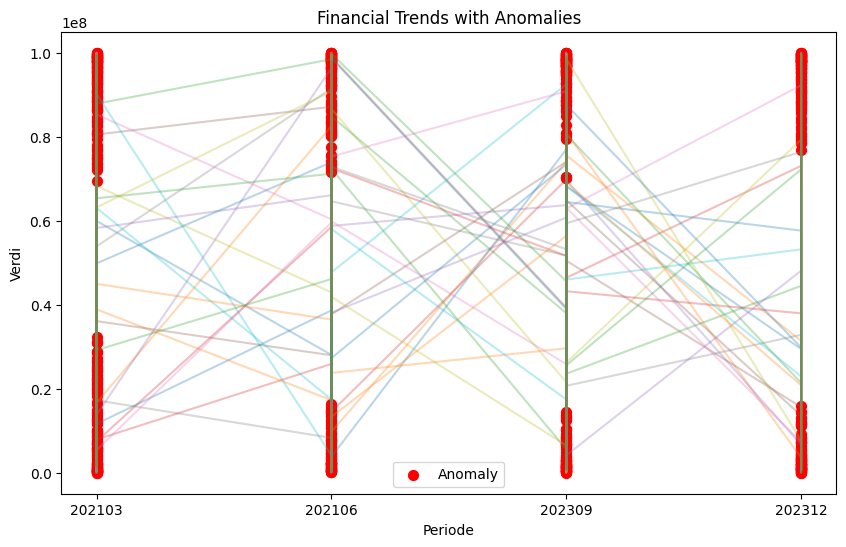

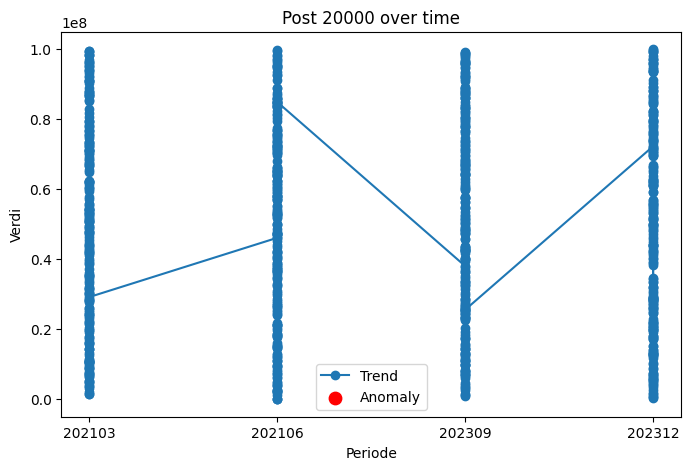

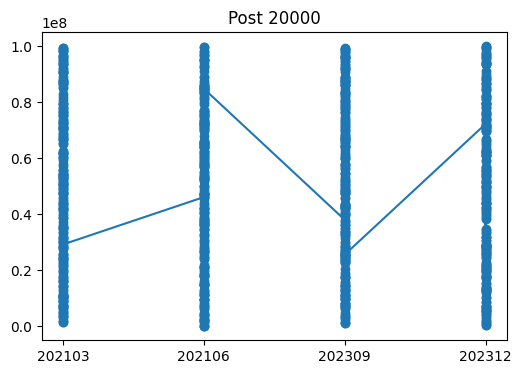

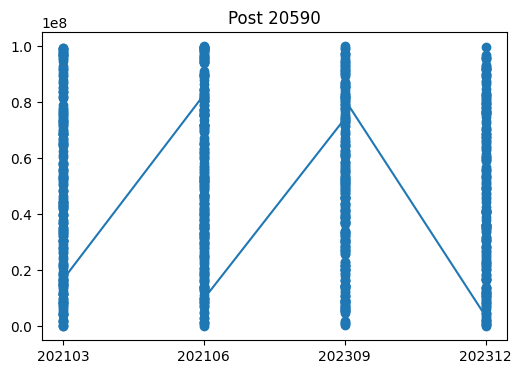

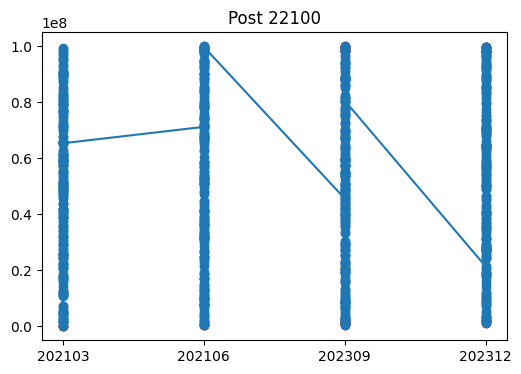

In [34]:
X = df[["verdi","post_code","periode_code"]]
y = df[["endring"]]

# # Apply ML model

# +
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)

df["anomaly"] = model.fit_predict(X)
# -

print(df.head())

# # Sort data by period

df = df.sort_values(by="periode")

# # Line plot

# +
plt.figure(figsize=(10,6))

# Plot all data (faint lines)
for post in df["post"].unique():
    subset = df[df["post"] == post]
    plt.plot(subset["periode"], subset["verdi"], alpha=0.3)

# Highlight anomalies
anomaly = df[df["anomaly"] == -1]
plt.scatter(anomaly["periode"], anomaly["verdi"], color="red", s=50, label="Anomaly")

plt.title("Financial Trends with Anomalies")
plt.xlabel("Periode")
plt.ylabel("Verdi")
plt.legend()

plt.show()

# +
post_example = "20000"

subset = df[df["post"] == post_example]

plt.figure(figsize=(8,5))

plt.plot(subset["periode"], subset["verdi"], marker="o", label="Trend")
plt.scatter(subset[subset["anomaly"]==-1]["periode"],
            subset[subset["anomaly"]==-1]["verdi"],
            color="red", label="Anomaly", s=80)

plt.title(f"Post {post_example} over time")
plt.xlabel("Periode")
plt.ylabel("Verdi")
plt.legend()

plt.show()
# -

for post in ["20000","20590","22100"]:
    subset = df[df["post"] == post]

    plt.figure(figsize=(6,4))

    plt.plot(subset["periode"], subset["verdi"], marker="o")

    plt.scatter(subset[subset["anomaly"]==-1]["periode"],
                subset[subset["anomaly"]==-1]["verdi"],
                color="red")

    plt.title(f"Post {post}")
    plt.show()

subset = df[df["post"] == post_example]